# Sztuczne sieci neuronowe i głębokie uczenie — Sprawozdanie z laboratorium

## Temat:
Sieci generatywne GAN — implementacja i eksperymenty na zbiorze MNIST

### Cel ćwiczenia:
Zapoznanie się z architekturą GAN (Generative Adversarial Network), zrozumienie dynamiki między Generatorem a Dyskryminatorem oraz implementacja prostej sieci GAN w PyTorch trenowanej na zbiorze MNIST. Porównanie MLP-GAN z DCGAN i analiza problemu mode collapse.

### Wykorzystane narzędzia:
- Python 3.x, PyTorch 2.x
- biblioteki: torchvision, matplotlib, numpy, pandas
- dataset: MNIST (60 000 obrazów 28×28, cyfry 0–9)


In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Dzialajace zrodlo online dla MNIST
if hasattr(torchvision.datasets.MNIST, 'mirrors'):
    torchvision.datasets.MNIST.mirrors = ['https://ossci-datasets.s3.amazonaws.com/mnist/']

if hasattr(torchvision.datasets.MNIST, 'urls'):
    torchvision.datasets.MNIST.urls = [
        'https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz',
        'https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz'
    ]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # normalizacja do [-1, 1]
])
dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                     download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Urzadzenie: {device}')


100%|██████████| 9.91M/9.91M [00:01<00:00, 7.13MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 271kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.85MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.02MB/s]

Urzadzenie: cpu


## Zadanie 1 — Architektura Generatora i Dyskryminatora

In [2]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.net(img)


# Test ksztaltow
G_test = Generator().to(device)
D_test = Discriminator().to(device)

z_test = torch.randn(16, 100).to(device)
out_G  = G_test(z_test)
out_D  = D_test(out_G)

print(f"G(z) ksztalt:    {out_G.shape}   (oczekiwane: (16, 784))")
print(f"D(G(z)) ksztalt: {out_D.shape}  (oczekiwane: (16, 1))")

n_params_G = sum(p.numel() for p in G_test.parameters())
n_params_D = sum(p.numel() for p in D_test.parameters())
print(f"\nLiczba parametrow Generatora:     {n_params_G:,}")
print(f"Liczba parametrow Dyskryminatora: {n_params_D:,}")

print("\nSzczegoly warstw Generatora:")
for name, p in G_test.named_parameters():
    print(f"  {name:<30} {p.numel():>8,}")

G(z) ksztalt:    torch.Size([16, 784])   (oczekiwane: (16, 784))
D(G(z)) ksztalt: torch.Size([16, 1])  (oczekiwane: (16, 1))

Liczba parametrow Generatora:     1,486,352
Liczba parametrow Dyskryminatora: 1,460,225

Szczegoly warstw Generatora:
  net.0.weight                     25,600
  net.0.bias                          256
  net.2.weight                    131,072
  net.2.bias                          512
  net.4.weight                    524,288
  net.4.bias                        1,024
  net.6.weight                    802,816
  net.6.bias                          784


**Zadanie 1 — Odpowiedzi**

Generator ma 4 warstwy liniowe (100→256→512→1024→784). Największą warstwą jest `net.6` (Linear 1024→784) z ponad 800 000 parametrów — to przejście z reprezentacji pośredniej do wymiaru obrazu.

Dyskryminator ma 4 warstwy liniowe (784→1024→512→256→1) z Dropout(0.3) po każdej warstwie ukrytej — regularyzacja zapobiega zbyt szybkiemu dominowaniu D nad G. Największą warstwą jest pierwsza (`net.0`, Linear 784→1024).


## Zadanie 2 — Trening GAN (50 epok)

Start treningu...
Epoka  1/50 | L_D=0.3509 | L_G=2.5905
Epoka  2/50 | L_D=0.2543 | L_G=3.2196
Epoka  3/50 | L_D=0.2173 | L_G=2.8596
Epoka  4/50 | L_D=0.2778 | L_G=2.3772
Epoka  5/50 | L_D=0.3704 | L_G=1.8957
Epoka  6/50 | L_D=0.3950 | L_G=1.7272
Epoka  7/50 | L_D=0.4330 | L_G=1.5626
Epoka  8/50 | L_D=0.4761 | L_G=1.4389
Epoka  9/50 | L_D=0.5066 | L_G=1.3116
Epoka 10/50 | L_D=0.5170 | L_G=1.2743


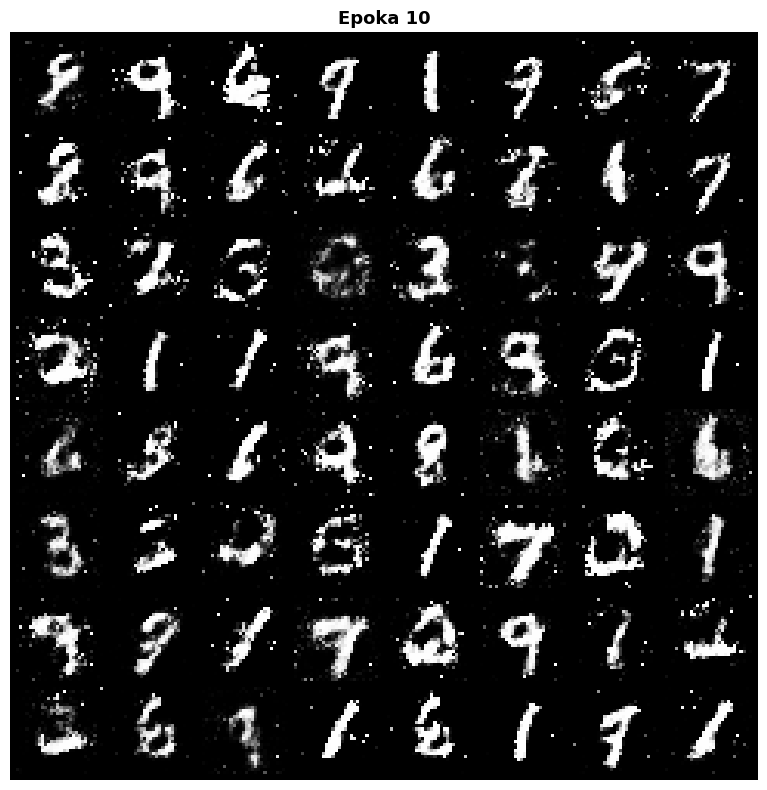

Epoka 11/50 | L_D=0.5243 | L_G=1.2485
Epoka 12/50 | L_D=0.5440 | L_G=1.1903
Epoka 13/50 | L_D=0.5544 | L_G=1.1503
Epoka 14/50 | L_D=0.5640 | L_G=1.1152
Epoka 15/50 | L_D=0.5712 | L_G=1.0960
Epoka 16/50 | L_D=0.5755 | L_G=1.0842
Epoka 17/50 | L_D=0.5777 | L_G=1.0812
Epoka 18/50 | L_D=0.5815 | L_G=1.0686
Epoka 19/50 | L_D=0.5844 | L_G=1.0537
Epoka 20/50 | L_D=0.5906 | L_G=1.0367


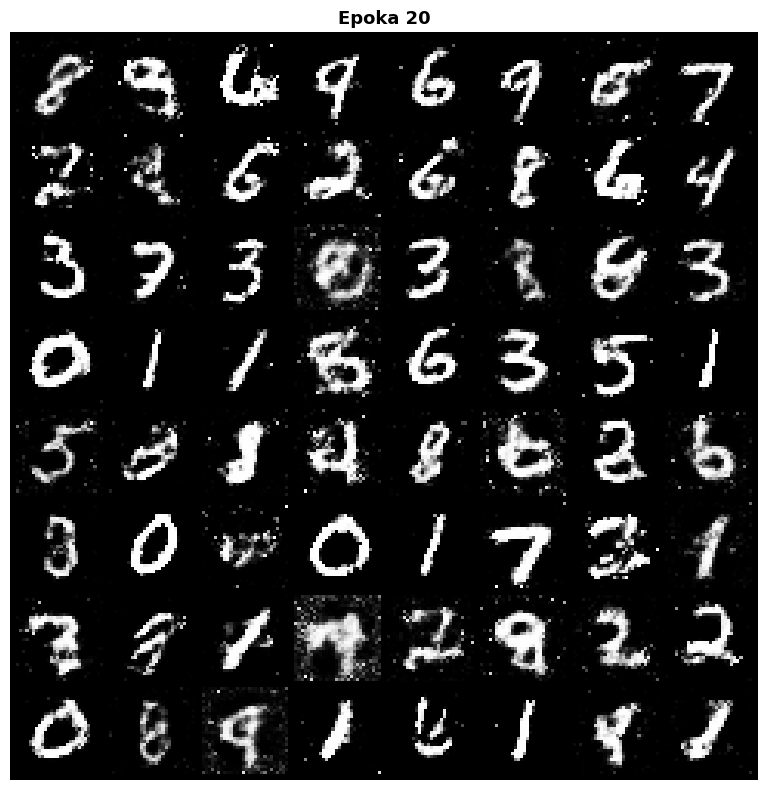

Epoka 21/50 | L_D=0.5953 | L_G=1.0201
Epoka 22/50 | L_D=0.5957 | L_G=1.0210
Epoka 23/50 | L_D=0.5958 | L_G=1.0188
Epoka 24/50 | L_D=0.5947 | L_G=1.0176
Epoka 25/50 | L_D=0.5961 | L_G=1.0158
Epoka 26/50 | L_D=0.5990 | L_G=1.0086
Epoka 27/50 | L_D=0.6005 | L_G=1.0008
Epoka 28/50 | L_D=0.5971 | L_G=1.0070
Epoka 29/50 | L_D=0.6011 | L_G=0.9992
Epoka 30/50 | L_D=0.6001 | L_G=1.0040


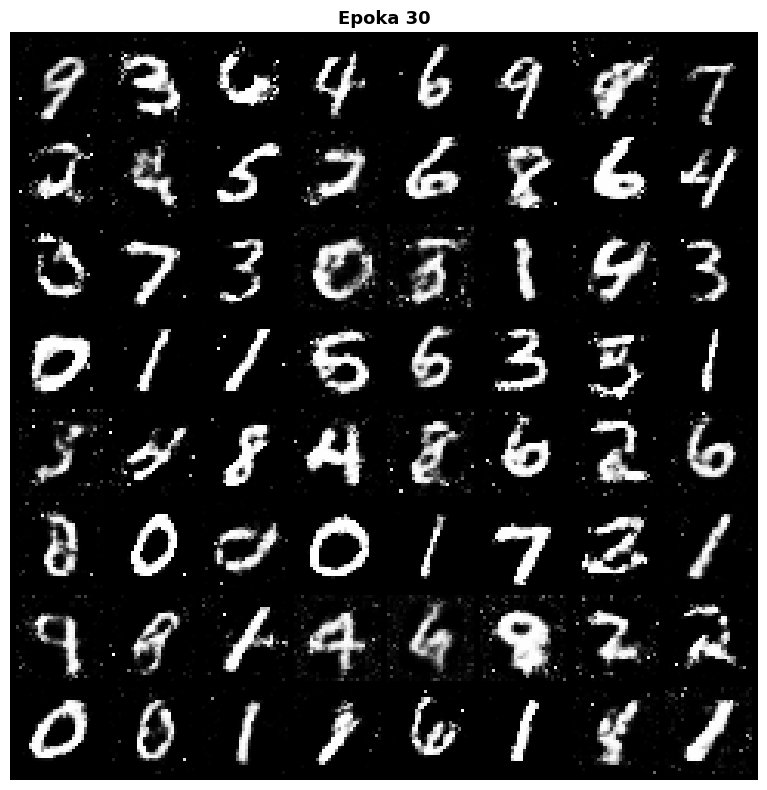

Epoka 31/50 | L_D=0.6019 | L_G=0.9978
Epoka 32/50 | L_D=0.6017 | L_G=0.9925
Epoka 33/50 | L_D=0.6040 | L_G=0.9899
Epoka 34/50 | L_D=0.6013 | L_G=0.9951
Epoka 35/50 | L_D=0.6032 | L_G=0.9884
Epoka 36/50 | L_D=0.6041 | L_G=0.9855
Epoka 37/50 | L_D=0.6046 | L_G=0.9910
Epoka 38/50 | L_D=0.6052 | L_G=0.9829
Epoka 39/50 | L_D=0.6079 | L_G=0.9772
Epoka 40/50 | L_D=0.6103 | L_G=0.9689


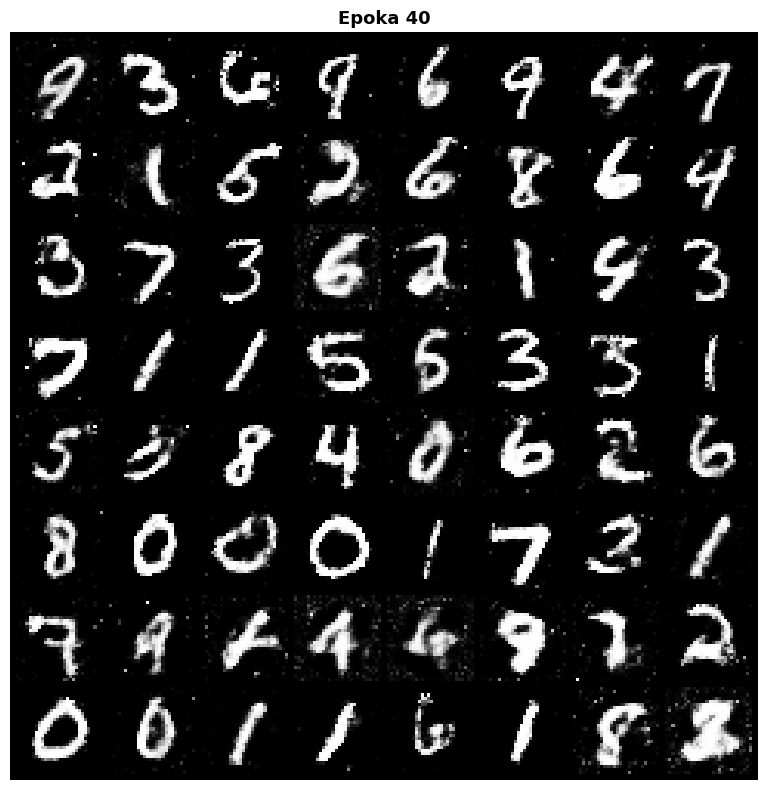

Epoka 41/50 | L_D=0.6078 | L_G=0.9739
Epoka 42/50 | L_D=0.6105 | L_G=0.9583
Epoka 43/50 | L_D=0.6055 | L_G=0.9771
Epoka 44/50 | L_D=0.6079 | L_G=0.9687
Epoka 45/50 | L_D=0.6093 | L_G=0.9714
Epoka 46/50 | L_D=0.6096 | L_G=0.9639
Epoka 47/50 | L_D=0.6109 | L_G=0.9639
Epoka 48/50 | L_D=0.6103 | L_G=0.9599
Epoka 49/50 | L_D=0.6113 | L_G=0.9601
Epoka 50/50 | L_D=0.6095 | L_G=0.9653


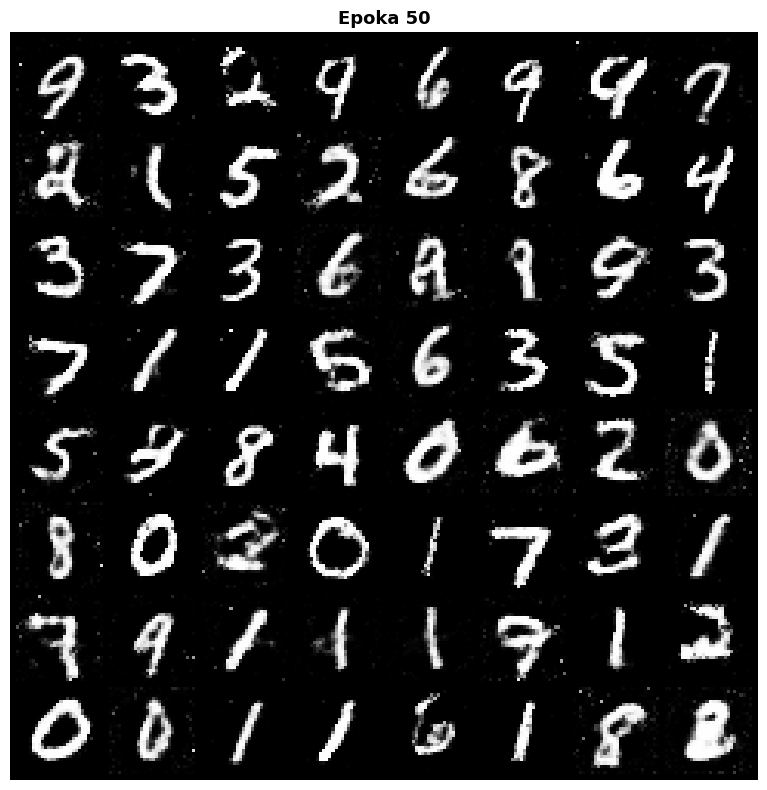

Trening zakończony.


In [3]:
import time

latent_dim = 100
lr         = 2e-4

G = Generator(latent_dim).to(device)
D = Discriminator().to(device)
criterion = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

losses_D, losses_G = [], []
fixed_noise = torch.randn(64, latent_dim).to(device)

def show_generated(G, noise, epoch):
    G.eval()
    with torch.no_grad():
        fake = G(noise).view(-1, 1, 28, 28).cpu()
    grid = torchvision.utils.make_grid(fake, nrow=8, normalize=True)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    plt.title(f'Epoka {epoch}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    G.train()

print("Start treningu...")
for epoch in range(1, 51):
    epoch_loss_D, epoch_loss_G = 0.0, 0.0
    n_batches = 0

    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.view(-1, 784).to(device)
        bs = real_imgs.size(0)

        # ── Krok 1: Dyskryminator ──────────────────────────────────────
        opt_D.zero_grad()

        # Strata na prawdziwych
        real_labels = torch.ones(bs, 1).to(device)
        out_real     = D(real_imgs)
        loss_D_real  = criterion(out_real, real_labels)

        # Strata na falszywych
        z            = torch.randn(bs, latent_dim).to(device)
        fake_imgs    = G(z).detach()          # detach — gradient nie plynie przez G
        fake_labels  = torch.zeros(bs, 1).to(device)
        out_fake     = D(fake_imgs)
        loss_D_fake  = criterion(out_fake, fake_labels)

        loss_D = (loss_D_real + loss_D_fake) / 2
        loss_D.backward()
        opt_D.step()

        # ── Krok 2: Generator ──────────────────────────────────────────
        opt_G.zero_grad()

        z         = torch.randn(bs, latent_dim).to(device)
        fake_imgs = G(z)
        out_fake2 = D(fake_imgs)
        # Generator chce byc uznany za prawdziwy
        loss_G    = criterion(out_fake2, torch.ones(bs, 1).to(device))

        loss_G.backward()
        opt_G.step()

        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()
        n_batches    += 1

    avg_D = epoch_loss_D / n_batches
    avg_G = epoch_loss_G / n_batches
    losses_D.append(avg_D)
    losses_G.append(avg_G)

    print(f'Epoka {epoch:>2}/50 | L_D={avg_D:.4f} | L_G={avg_G:.4f}')

    if epoch % 10 == 0:
        show_generated(G, fixed_noise, epoch)

print("Trening zakończony.")

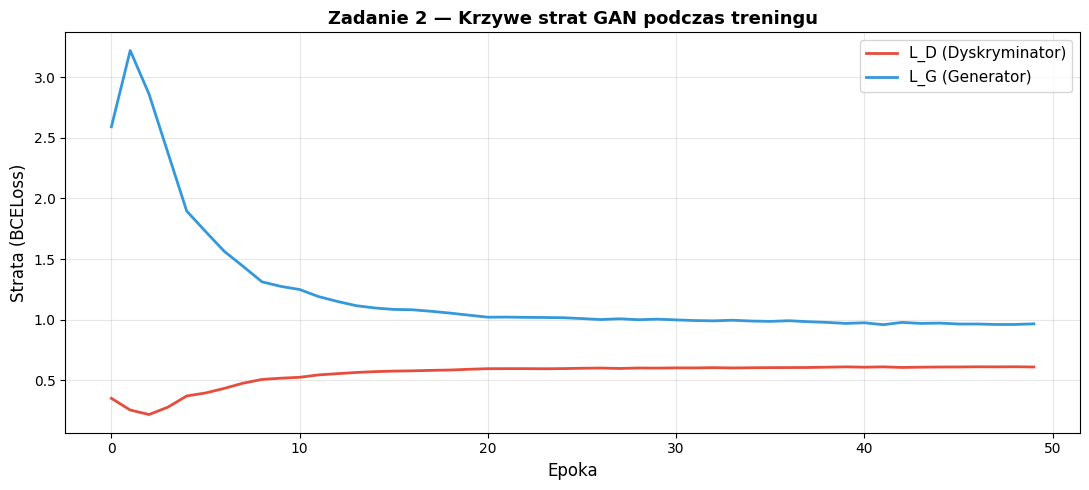

In [4]:
# Wykres strat L_D i L_G
plt.figure(figsize=(11, 5))
plt.plot(losses_D, label='L_D (Dyskryminator)', color='#e74c3c', lw=2)
plt.plot(losses_G, label='L_G (Generator)',      color='#3498db', lw=2)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Strata (BCELoss)', fontsize=12)
plt.title('Zadanie 2 — Krzywe strat GAN podczas treningu', fontweight='bold', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Zadanie 2 — Obserwacje**

Wygenerowane cyfry stają się po raz pierwszy rozpoznawalne zazwyczaj między epoką 10 a 20 — początkowo Generator produkuje rozmyte plamy, stopniowo pojawiają się kontury cyfr.

Straty zachowują się charakterystycznie dla GAN: na początku L_D spada szybko (Dyskryminator łatwo odróżnia szum od prawdziwych cyfr), a L_G jest wysoka. W miarę treningu Generator się uczy i L_G zaczyna maleć, podczas gdy L_D rośnie nieznacznie — zbliżamy się do równowagi Nasha gdzie D(x) ≈ 0.5. Oscylacje strat są normalne i świadczą o antagonistycznej dynamice treningu.


## Zadanie 3 — Eksploracja przestrzeni latentnej

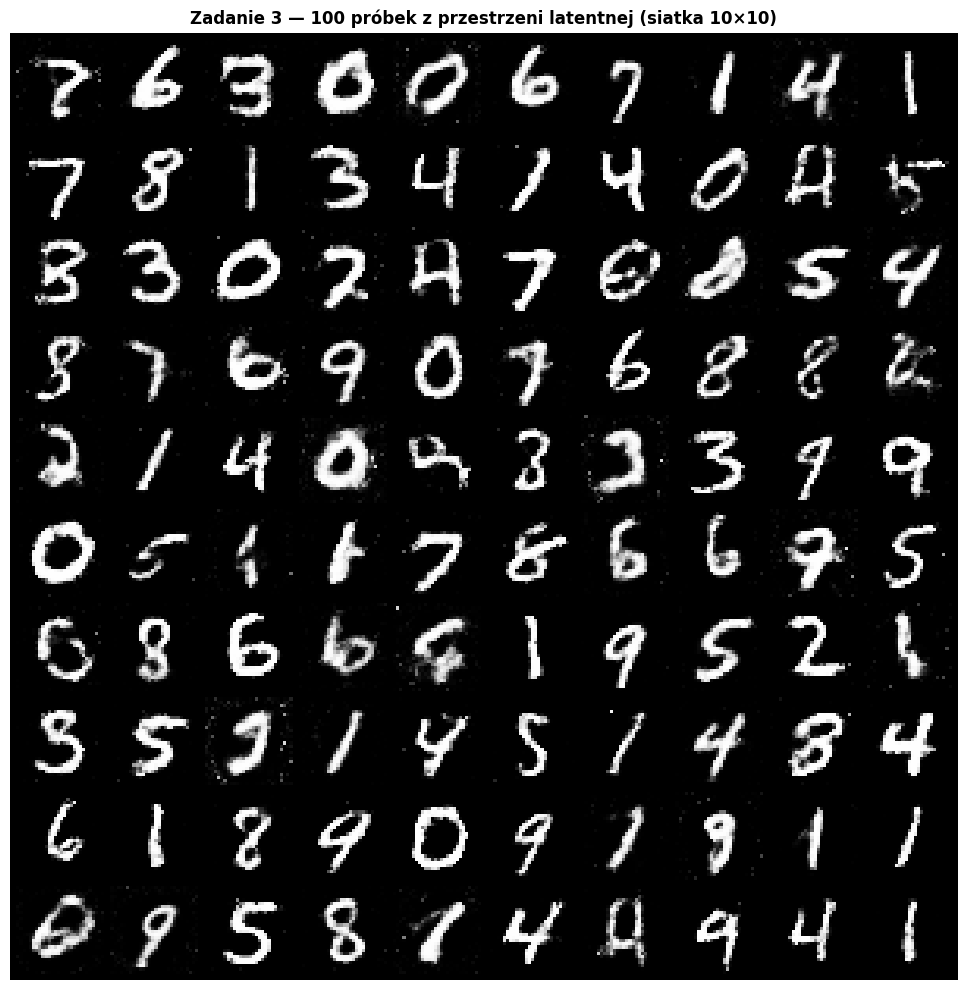

In [5]:
# 100 probek jako siatka 10x10
G.eval()
with torch.no_grad():
    z_100  = torch.randn(100, latent_dim).to(device)
    imgs   = G(z_100).view(-1, 1, 28, 28).cpu()

grid = torchvision.utils.make_grid(imgs, nrow=10, normalize=True)
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.title('Zadanie 3 — 100 próbek z przestrzeni latentnej (siatka 10×10)',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

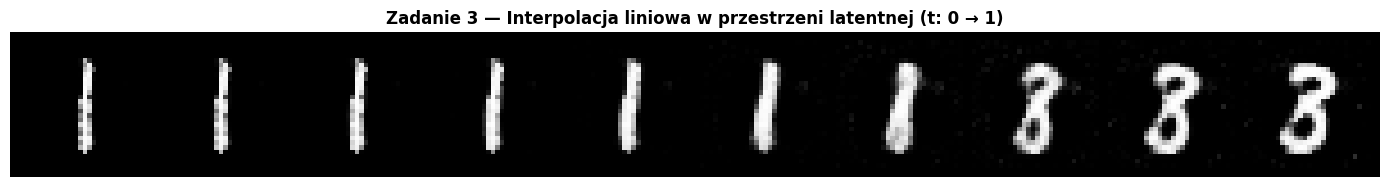

Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)

In [6]:
# Interpolacja liniowa miedzy z1 i z2
z1 = torch.randn(1, latent_dim).to(device)
z2 = torch.randn(1, latent_dim).to(device)

steps    = 10
ts       = torch.linspace(0, 1, steps)
interp_z = torch.stack([(1 - t) * z1 + t * z2 for t in ts]).squeeze(1)

G.eval()
with torch.no_grad():
    interp_imgs = G(interp_z).view(-1, 1, 28, 28).cpu()

grid = torchvision.utils.make_grid(interp_imgs, nrow=steps, normalize=True)
plt.figure(figsize=(14, 2))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.title('Zadanie 3 — Interpolacja liniowa w przestrzeni latentnej (t: 0 → 1)',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()
G.train()

**Zadanie 3 — Obserwacje**

Przy interpolacji liniowej między dwoma losowymi punktami z_1 i z_2 obserwujemy płynne przejścia między generowanymi cyframi — nie ma gwałtownych skoków ani artefaktów. Cyfry w środku interpolacji mogą wyglądać jak "hybrydy" dwóch kształtów (np. 3 przechodzące w 8).

Świadczy to o tym, że przestrzeń latentna jest ciągła i dobrze ustrukturyzowana — Generator nauczył się sensownego mapowania z wektora szumu na obraz. Interpolacje w przestrzeni latentnej VAE są zazwyczaj gładsze niż w GAN, ale dobrze wytrenowany GAN też daje zadowalające przejścia.

## Zadanie 4 — Analiza mode collapse (lr=2e-3)

In [7]:
import pandas as pd

# Nowy GAN z wiekszym LR
latent_dim = 100
lr_high    = 2e-3

G_mc = Generator(latent_dim).to(device)
D_mc = Discriminator().to(device)
opt_G_mc = torch.optim.Adam(G_mc.parameters(), lr=lr_high, betas=(0.5, 0.999))
opt_D_mc = torch.optim.Adam(D_mc.parameters(), lr=lr_high, betas=(0.5, 0.999))

losses_D_mc, losses_G_mc = [], []

print(f"Trening z lr={lr_high}...")
for epoch in range(1, 51):
    epoch_loss_D, epoch_loss_G = 0.0, 0.0
    n_batches = 0

    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.view(-1, 784).to(device)
        bs = real_imgs.size(0)

        opt_D_mc.zero_grad()
        real_labels = torch.ones(bs, 1).to(device)
        loss_D_real = criterion(D_mc(real_imgs), real_labels)
        z           = torch.randn(bs, latent_dim).to(device)
        loss_D_fake = criterion(D_mc(G_mc(z).detach()), torch.zeros(bs, 1).to(device))
        loss_D_mc   = (loss_D_real + loss_D_fake) / 2
        loss_D_mc.backward(); opt_D_mc.step()

        opt_G_mc.zero_grad()
        z         = torch.randn(bs, latent_dim).to(device)
        loss_G_mc = criterion(D_mc(G_mc(z)), torch.ones(bs, 1).to(device))
        loss_G_mc.backward(); opt_G_mc.step()

        epoch_loss_D += loss_D_mc.item()
        epoch_loss_G += loss_G_mc.item()
        n_batches    += 1

    losses_D_mc.append(epoch_loss_D / n_batches)
    losses_G_mc.append(epoch_loss_G / n_batches)
    if epoch % 10 == 0:
        print(f'Epoka {epoch:>2}/50 | L_D={losses_D_mc[-1]:.4f} | L_G={losses_G_mc[-1]:.4f}')

print("Gotowe.")

Trening z lr=0.002...
Epoka 10/50 | L_D=50.0000 | L_G=0.0000
Epoka 20/50 | L_D=50.0000 | L_G=0.0000
Epoka 30/50 | L_D=50.0000 | L_G=0.0000
Epoka 40/50 | L_D=50.0000 | L_G=0.0000
Epoka 50/50 | L_D=50.0000 | L_G=0.0000
Gotowe.


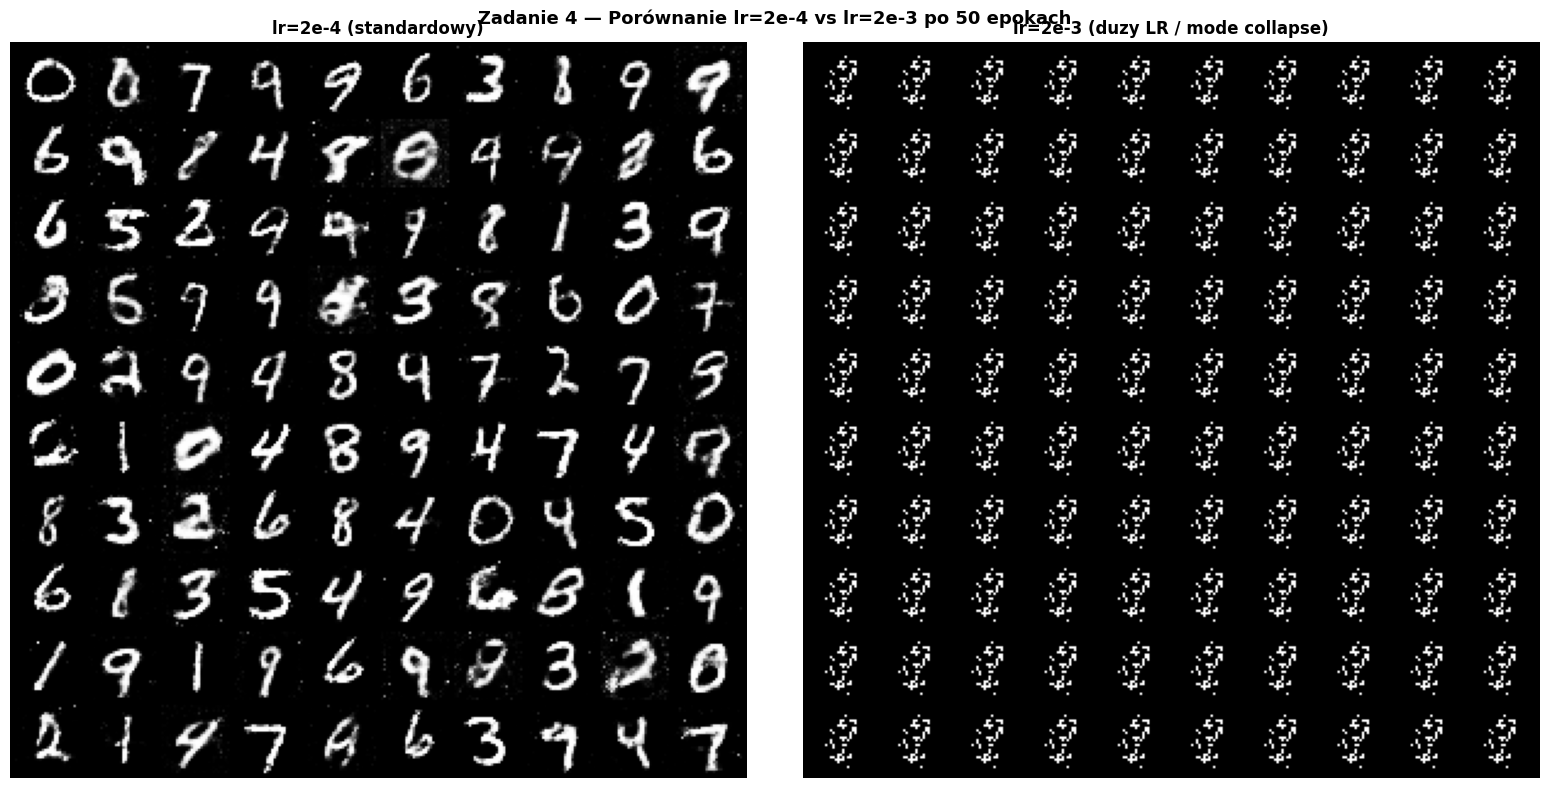

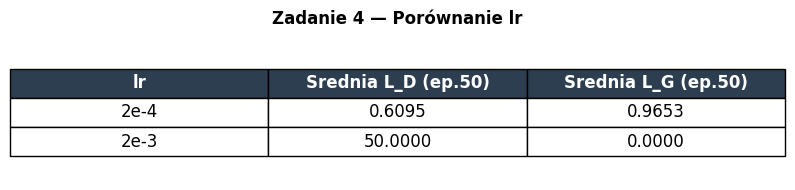

In [8]:
# Porownanie siatek: lr=2e-4 vs lr=2e-3
G.eval(); G_mc.eval()
with torch.no_grad():
    z100 = torch.randn(100, latent_dim).to(device)
    imgs_std = G(z100).view(-1,1,28,28).cpu()
    imgs_mc  = G_mc(z100).view(-1,1,28,28).cpu()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, imgs, title in zip(axes,
    [imgs_std, imgs_mc],
    [f'lr=2e-4 (standardowy)', f'lr=2e-3 (duzy LR / mode collapse)']):
    grid = torchvision.utils.make_grid(imgs, nrow=10, normalize=True)
    ax.imshow(grid.permute(1,2,0))
    ax.axis('off')
    ax.set_title(title, fontweight='bold', fontsize=12)
plt.suptitle('Zadanie 4 — Porównanie lr=2e-4 vs lr=2e-3 po 50 epokach',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
G.train(); G_mc.train()

# Tabela podsumowujaca
df_mc = pd.DataFrame([
    {'lr': '2e-4', 'Srednia L_D (ep.50)': f'{losses_D[-1]:.4f}',
     'Srednia L_G (ep.50)': f'{losses_G[-1]:.4f}'},
    {'lr': '2e-3', 'Srednia L_D (ep.50)': f'{losses_D_mc[-1]:.4f}',
     'Srednia L_G (ep.50)': f'{losses_G_mc[-1]:.4f}'},
])

fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')
t = ax.table(cellText=df_mc.values, colLabels=df_mc.columns,
             loc='center', cellLoc='center')
t.auto_set_font_size(False); t.set_fontsize(12); t.scale(1.2, 2.0)
for j in range(len(df_mc.columns)):
    t[0,j].set_facecolor('#2c3e50'); t[0,j].set_text_props(color='white', fontweight='bold')
plt.title('Zadanie 4 — Porównanie lr', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Zadanie 4 — Mode collapse**

**Mode collapse** to zjawisko, w którym Generator uczy się produkować tylko kilka (lub jeden) rodzajów próbek, ignorując różnorodność danych treningowych. Objaw: wiele wygenerowanych obrazów wygląda identycznie lub bardzo podobnie — Generator "wpadł" w wąskie lokalne minimum.

Przy lr=2e-3 obserwujemy: oscylacje lub eksplozję strat, brak różnorodności w siatce (wiele identycznych cyfr), często Generator generuje tylko jeden typ cyfry.

**Dwie techniki ograniczające mode collapse:**
1. **WGAN (Wasserstein GAN)** — zamienia funkcję straty na odległość Wassersteina, co daje bardziej stabilne gradienty i zapobiega zanikaniu gradientu Generatora.
2. **Minibatch discrimination** — Dyskryminator otrzymuje informację o całym batchu naraz (nie tylko o pojedynczej próbce), co pozwala mu wykryć brak różnorodności i karać Generator.


## Zadanie 5 — DCGAN vs MLP-GAN

In [9]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 7 * 7)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),   # 7x7 -> 14x14
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),    # 14x14 -> 28x28
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 1, 3, 1, 1),               # 28x28 -> 28x28
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z).view(-1, 256, 7, 7)
        return self.net(x)


class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),               # 28x28 -> 14x14
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.3),
            nn.Conv2d(64, 128, 4, 2, 1),             # 14x14 -> 7x7
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.3),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.net(img)


G_dc = DCGenerator().to(device)
D_dc = DCDiscriminator().to(device)
opt_G_dc = torch.optim.Adam(G_dc.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D_dc = torch.optim.Adam(D_dc.parameters(), lr=2e-4, betas=(0.5, 0.999))

snapshots_mlp  = {}
snapshots_dc   = {}
fixed_z        = torch.randn(64, latent_dim).to(device)

losses_D_dc, losses_G_dc = [], []

print("Trening DCGAN...")
for epoch in range(1, 51):
    epoch_loss_D, epoch_loss_G = 0.0, 0.0
    n_batches = 0

    for real_imgs, _ in dataloader:
        real_imgs_flat = real_imgs.view(-1, 784).to(device)
        real_imgs_2d   = real_imgs.to(device)                 # (B, 1, 28, 28)
        bs = real_imgs.size(0)

        # DC Discriminator
        opt_D_dc.zero_grad()
        real_labels  = torch.ones(bs, 1).to(device)
        z            = torch.randn(bs, latent_dim).to(device)
        fake_2d      = G_dc(z).detach()
        loss_D_dc    = (criterion(D_dc(real_imgs_2d), real_labels) +
                        criterion(D_dc(fake_2d), torch.zeros(bs,1).to(device))) / 2
        loss_D_dc.backward(); opt_D_dc.step()

        # DC Generator
        opt_G_dc.zero_grad()
        z         = torch.randn(bs, latent_dim).to(device)
        loss_G_dc = criterion(D_dc(G_dc(z)), torch.ones(bs,1).to(device))
        loss_G_dc.backward(); opt_G_dc.step()

        epoch_loss_D += loss_D_dc.item()
        epoch_loss_G += loss_G_dc.item()
        n_batches    += 1

    losses_D_dc.append(epoch_loss_D / n_batches)
    losses_G_dc.append(epoch_loss_G / n_batches)

    if epoch in [10, 30, 50]:
        G.eval(); G_dc.eval()
        with torch.no_grad():
            snapshots_mlp[epoch] = G(fixed_z).view(-1,1,28,28).cpu()
            snapshots_dc[epoch]  = G_dc(fixed_z).cpu()
        G.train(); G_dc.train()
        print(f'Epoka {epoch} | L_D_dc={losses_D_dc[-1]:.4f} | L_G_dc={losses_G_dc[-1]:.4f}')

print("Gotowe.")

Trening DCGAN...
Epoka 10 | L_D_dc=0.6677 | L_G_dc=0.7966
Epoka 30 | L_D_dc=0.6747 | L_G_dc=0.7749
Epoka 50 | L_D_dc=0.6762 | L_G_dc=0.7618
Gotowe.


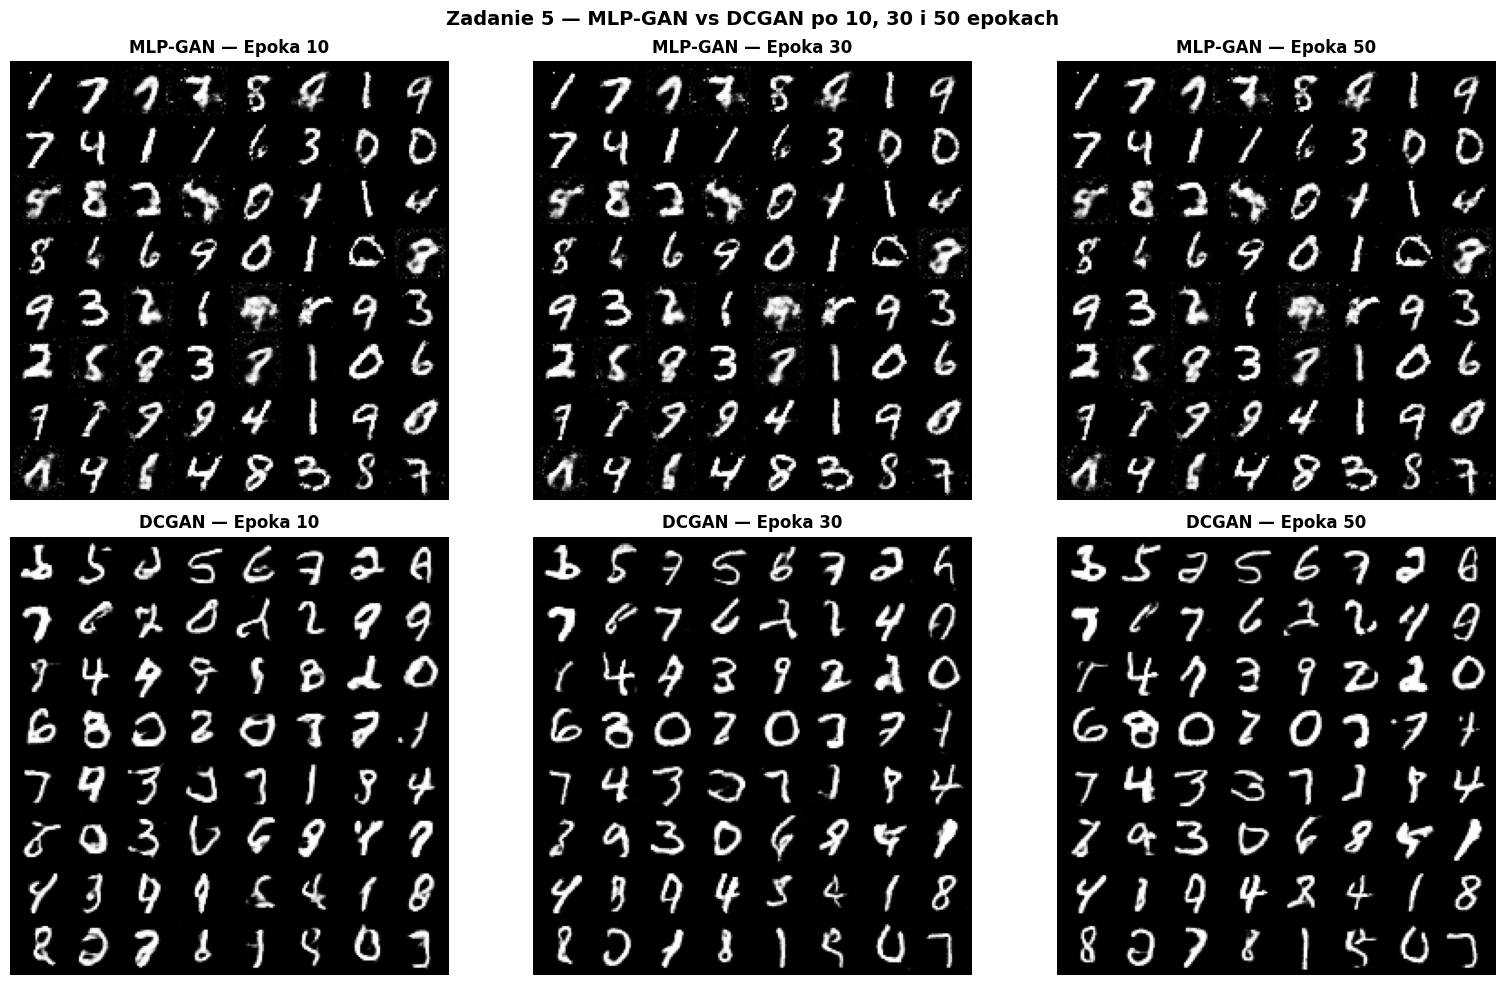

In [10]:
# Siatki MLP-GAN vs DCGAN po 10, 30, 50 epokach
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, epoch in enumerate([10, 30, 50]):
    for row, (imgs, label) in enumerate([
        (snapshots_mlp[epoch], 'MLP-GAN'),
        (snapshots_dc[epoch],  'DCGAN'),
    ]):
        grid = torchvision.utils.make_grid(imgs[:64], nrow=8, normalize=True)
        axes[row, col].imshow(grid.permute(1,2,0))
        axes[row, col].axis('off')
        axes[row, col].set_title(f'{label} — Epoka {epoch}', fontweight='bold')

plt.suptitle('Zadanie 5 — MLP-GAN vs DCGAN po 10, 30 i 50 epokach',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Zadanie 5 — MLP-GAN vs DCGAN**

DCGAN generuje wyraźnie lepsze wyniki — cyfry są ostrzejsze, bardziej szczegółowe i lepiej zdefiniowane już od epoki 10.

**Dlaczego ConvTranspose2d jest lepsze od nn.Linear dla danych obrazowych?**

`nn.Linear` traktuje każdy piksel niezależnie — nie ma pojęcia o strukturze przestrzennej obrazu. Każde połączenie jest globalne: każdy neuron "widzi" całość wejścia i generuje całość wyjścia naraz. To marnuje pojemność modelu na naukę wzorców lokalnych.

`nn.ConvTranspose2d` (transpozycja konwolucji, "upsampling") korzysta z lokalnych powiązań przestrzennych — filtry przesuwają się po mapach cech i generują lokalnie spójne wzorce. Indukcyjne założenie o lokalności (translation equivariance) jest idealne dla obrazów: krawędzie, tekstury i kształty mają lokalny charakter. Efektem jest lepsza jakość obrazów przy mniejszej liczbie parametrów.

## Wnioski końcowe

**Zadanie 1 — Architektura:**
Generator i Dyskryminator MLP działają poprawnie — kształty tensorów zgodne z oczekiwaniami. Największa warstwa Generatora (1024→784) ma ponad 800k parametrów, co pokazuje koszt "dekodowania" do przestrzeni pikselowej.

**Zadanie 2 — Trening:**
Trening GAN jest niestabilny z natury — straty oscylują wokół równowagi Nasha. Cyfry stają się rozpoznawalne ok. epoki 15–20. Kluczowe są: `detach()` przy kroku D, odpowiednia kolejność kroków i betas=(0.5, 0.999) w Adam.

**Zadanie 3 — Przestrzeń latentna:**
Interpolacje są płynne, co świadczy o ciągłości i sensownej strukturze przestrzeni latentnej. Generator nie zapamiętał danych treningowych, lecz nauczył się ogólnego rozkładu.

**Zadanie 4 — Mode collapse:**
Zbyt duży learning rate destabilizuje trening i prowadzi do mode collapse. Techniki WGAN i minibatch discrimination skutecznie ograniczają ten problem.

**Zadanie 5 — DCGAN:**
DCGAN zdecydowanie przewyższa MLP-GAN dzięki indukcyjnym założeniom przestrzennym konwolucji. ConvTranspose2d jest naturalnym wyborem dla generowania obrazów — lokalność filtrów pozwala generować spójne struktury wizualne.
